# Complete Exploratory Data Analysis

## Palmer Penguins Dataset

This notebook presents a complete exploratory data analysis of the Palmer Penguins dataset. The analysis combines descriptive statistics, data-quality checks, univariate analysis, outlier investigation, bivariate analysis, and correlation analysis.

The main goal is to understand the structure of the dataset, discover meaningful relationships between the penguins' physical measurements, and identify features that may be useful in a future machine-learning model.

## Analysis Objectives

In this analysis, I will:

- inspect the dataset's structure and data quality;
- review the distributions of the numeric and categorical variables;
- examine relationships between physical measurements;
- compare numeric measurements across penguin groups;
- calculate and interpret correlations between numeric features;
- summarize the main findings and their possible importance for future modeling.

## Questions to Explore

The analysis will focus on the following questions:

1. Is body mass related to flipper length?
2. Do bill measurements differ between penguin species?
3. Does body mass vary across species and sex groups?
4. Which physical measurements have the strongest linear relationships?
5. Which features may be useful for predicting a penguin's species in a future classification model?

## Importing the Libraries

The analysis uses Pandas for loading and manipulating the dataset, NumPy for numerical operations, and Matplotlib and Seaborn for data visualization.

A consistent Seaborn theme is also applied so that the plots remain clear and visually consistent throughout the notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Loading the Dataset

The Palmer Penguins dataset is stored in the shared `data` folder for Week 2. It is loaded using a relative path so that the notebook can run correctly without depending on an absolute path from one specific computer.

After loading the file, the first five rows are displayed to confirm that the data was read correctly.

In [2]:
penguins = pd.read_csv("../data/penguins.csv")

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## Initial Dataset Inspection

Before analysing relationships, it is important to understand the basic structure of the dataset. This includes the number of rows and columns, the column names, and the data type stored in each column.

This inspection also helps distinguish between numeric measurements, categorical variables, and columns that may need special interpretation.

In [3]:
print(f"Number of rows: {penguins.shape[0]}")
print(f"Number of columns: {penguins.shape[1]}")

print("\nColumn names:")
print(penguins.columns.tolist())

print("\nDataset information:")
penguins.info()

Number of rows: 344
Number of columns: 8

Column names:
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


## Data Quality Check

Before creating visualizations, the dataset is checked for missing values and duplicate rows.

Missing values do not always require the same treatment. The correct decision depends on the column, the amount of missing data, and the analysis being performed. Duplicate rows are checked separately because they may give some observations more influence than they should have.

In [4]:
missing=pd.DataFrame({
    "missing_count" : penguins.isna().sum() ,
    "missing_percentage" : (penguins.isna().mean()*100).round(2)
    })
missing=missing[missing["missing_count"]>0]

duplicate=penguins.duplicated().sum()

missing_by_row=penguins.isna().any(axis=1).sum()
print(f"missing :{missing}")
print()
print(f"missing number, by row :{missing_by_row}")
print()
print(f"duplicated rows : {duplicate}")

missing :                   missing_count  missing_percentage
bill_length_mm                 2                0.58
bill_depth_mm                  2                0.58
flipper_length_mm              2                0.58
body_mass_g                    2                0.58
sex                           11                3.20

missing number, by row :11

duplicated rows : 0


## Data Preparation Decisions

The original dataset will be kept unchanged, and a separate working copy will be used during the analysis.

The following decisions will guide the EDA:

- Missing values in `sex` will not be filled with the most frequent category because the true values are unknown.
- Rows will only be excluded temporarily when a specific plot requires complete values in selected columns.
- Missing physical measurements will not be replaced before examining the analysis in which they are needed.
- The Day 4 IQR analysis did not flag potential outliers in the four physical measurement columns, so these observations will be retained.
- The `year` column will be treated as a time label, not as a physical measurement, and will not be included in the main physical correlation matrix.

## Creating a Working Copy

A copy of the original DataFrame is created for the remaining analysis. This keeps the loaded dataset unchanged and makes later preparation steps easier to track.

In [5]:
eda_df = penguins.copy()

print(f"Original dataset shape: {penguins.shape}")
print(f"Working copy shape: {eda_df.shape}")

Original dataset shape: (344, 8)
Working copy shape: (344, 8)


## Brief Univariate and Outlier Recap

The full univariate analysis and outlier investigation were completed in the Day 4 notebook. This section includes a concise summary of the most important results so that the current notebook remains complete without repeating the full earlier analysis.

The recap covers descriptive statistics, numeric distributions, categorical frequencies, and an IQR-based outlier check for the physical measurements.

In [6]:
measurement_columns = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

measurement_labels = {
    "bill_length_mm": "Bill Length (mm)",
    "bill_depth_mm": "Bill Depth (mm)",
    "flipper_length_mm": "Flipper Length (mm)",
    "body_mass_g": "Body Mass (g)"
}

descriptive_summary = eda_df[measurement_columns].describe().T.round(2)

descriptive_summary

,count,mean,std,min,25%,50%,75%,max
bill_length_mm,342.0,43.92,5.46,32.1,39.22,44.45,48.5,59.6
bill_depth_mm,342.0,17.15,1.97,13.1,15.60,17.30,18.7,21.5
flipper_length_mm,342.0,200.92,14.06,172.0,190.00,197.00,213.0,231.0
body_mass_g,342.0,4201.75,801.95,2700.0,3550.00,4050.00,4750.0,6300.0


### Numeric Distribution Overview

The following histograms provide a compact review of the four physical measurements. They are included to show the overall shape, spread, and possible grouping within each numeric variable before examining relationships between variables.

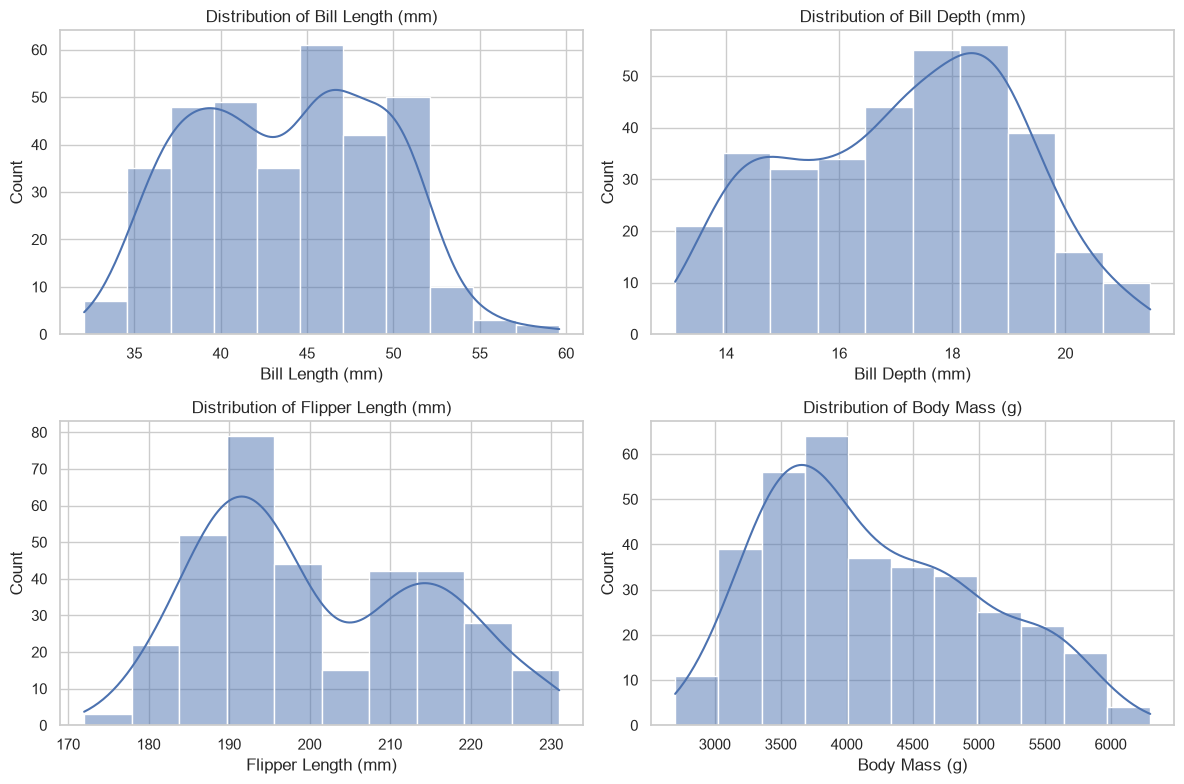

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, column in zip(axes.flatten(), measurement_columns):
    sns.histplot(
        data=eda_df,
        x=column,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Distribution of {measurement_labels[column]}")
    ax.set_xlabel(measurement_labels[column])
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Categorical Distribution Overview

The main categorical variables are reviewed using count plots. This helps show the number of observations in each species, island, and recorded sex category.

These counts are important because strongly unbalanced groups may affect comparisons and future model evaluation.

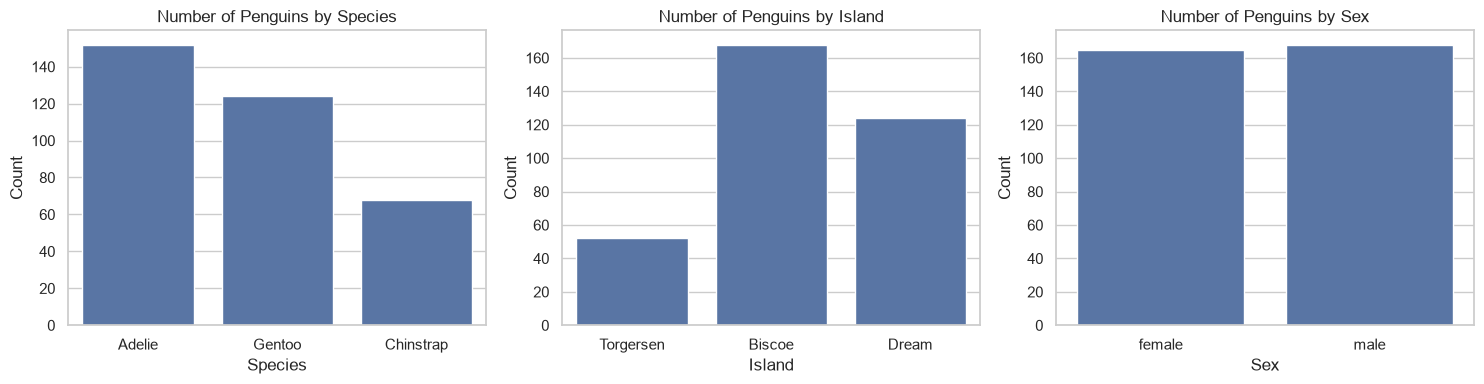

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(
    data=eda_df,
    x="species",
    ax=axes[0]
)

axes[0].set_title("Number of Penguins by Species")
axes[0].set_xlabel("Species")
axes[0].set_ylabel("Count")

sns.countplot(
    data=eda_df,
    x="island",
    ax=axes[1]
)

axes[1].set_title("Number of Penguins by Island")
axes[1].set_xlabel("Island")
axes[1].set_ylabel("Count")

sns.countplot(
    data=eda_df,
    x="sex",
    order=["female", "male"],
    ax=axes[2]
)

axes[2].set_title("Number of Penguins by Sex")
axes[2].set_xlabel("Sex")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

### IQR Outlier Check

The Day 4 analysis used the IQR rule to investigate potential outliers. The following table repeats only the final calculation for the four physical measurements.

The purpose is to document the lower and upper bounds and the number of observations flagged in each column. A flagged observation is treated as a value to investigate, not as an automatic deletion.

In [9]:
outlier_results = []

for column in measurement_columns:
    values = eda_df[column].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    potential_outliers = values[
        (values < lower_bound) |
        (values > upper_bound)
    ]

    outlier_results.append({
        "feature": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "potential_outliers": len(potential_outliers)
    })

outlier_summary = (
    pd.DataFrame(outlier_results)
    .set_index("feature")
    .round(2)
)

outlier_summary

,Q1,Q3,IQR,lower_bound,upper_bound,potential_outliers
feature,,,,,,
bill_length_mm,39.22,48.5,9.27,25.31,62.41,0
bill_depth_mm,15.60,18.7,3.10,10.95,23.35,0
flipper_length_mm,190.00,213.0,23.00,155.50,247.50,0
body_mass_g,3550.00,4750.0,1200.00,1750.00,6550.00,0


### Brief Recap Findings

The physical measurements contain 342 non-missing observations. Their distributions are not all represented by one simple symmetric shape; several show visible grouping, which is likely connected to differences between penguin species.

Adelie is the most represented species, followed by Gentoo and Chinstrap. The recorded female and male groups are nearly balanced, while the number of observations differs more clearly across species and islands.

The overall IQR check did not flag potential outliers in any of the four physical measurement columns. This does not prevent unusual values from appearing within smaller subgroups, but it supports keeping the observations in the main analysis.

## Bivariate Analysis

Univariate analysis examines one variable at a time, while bivariate analysis examines the relationship between two variables.

For two numeric variables, a scatter plot is useful because every point represents one observation. The position of the points can reveal the direction and strength of a relationship, clusters within the data, and unusual observations.

The following analysis focuses on selected physical measurements that may also be useful as features in a future classification model.

### Flipper Length and Body Mass

The first relationship examines whether penguins with longer flippers also tend to have greater body mass.

The points are coloured by species to determine whether the overall relationship is shared across the dataset or is partly influenced by differences between species.

Number of observations used: 342
Correlation between flipper length and body mass: 0.871


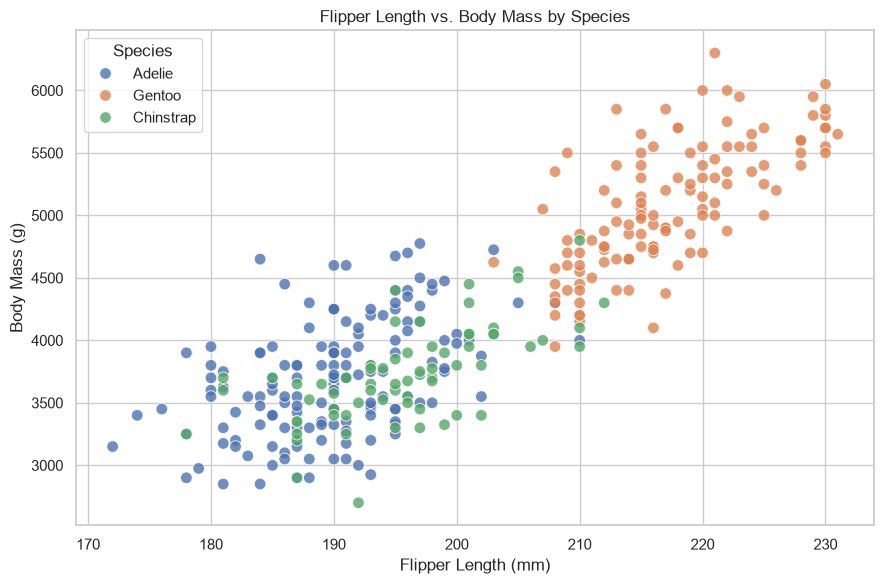

In [10]:
flipper_mass_df = eda_df[
    ["flipper_length_mm", "body_mass_g", "species"]
].dropna()

flipper_mass_correlation = flipper_mass_df[
    "flipper_length_mm"
].corr(flipper_mass_df["body_mass_g"])

print(f"Number of observations used: {len(flipper_mass_df)}")
print(
    "Correlation between flipper length and body mass: "
    f"{flipper_mass_correlation:.3f}"
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=flipper_mass_df,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    s=70,
    alpha=0.8
)

plt.title("Flipper Length vs. Body Mass by Species")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.legend(title="Species")
plt.tight_layout()
plt.show()

#### Interpretation

The scatter plot shows a strong positive relationship between flipper length and body mass (`r = 0.871`). Penguins with longer flippers generally tend to have greater body mass.

Gentoo penguins form a mostly separate group with longer flippers and higher body mass. Adelie and Chinstrap penguins overlap considerably, although Chinstrap penguins tend to have slightly longer flippers in this sample.

These measurements may therefore be useful for distinguishing Gentoo penguins, but they are unlikely to separate all three species reliably on their own. Their strong correlation also suggests that they capture some shared information about overall body size.

### Bill Length and Bill Depth

The second relationship examines the two bill measurements.

An overall correlation value alone may hide differences between species. Therefore, the scatter plot uses species colours to show whether the measurements form distinct groups and whether the relationship appears similar within each group.

Number of observations used: 342
Correlation between bill length and bill depth: -0.235


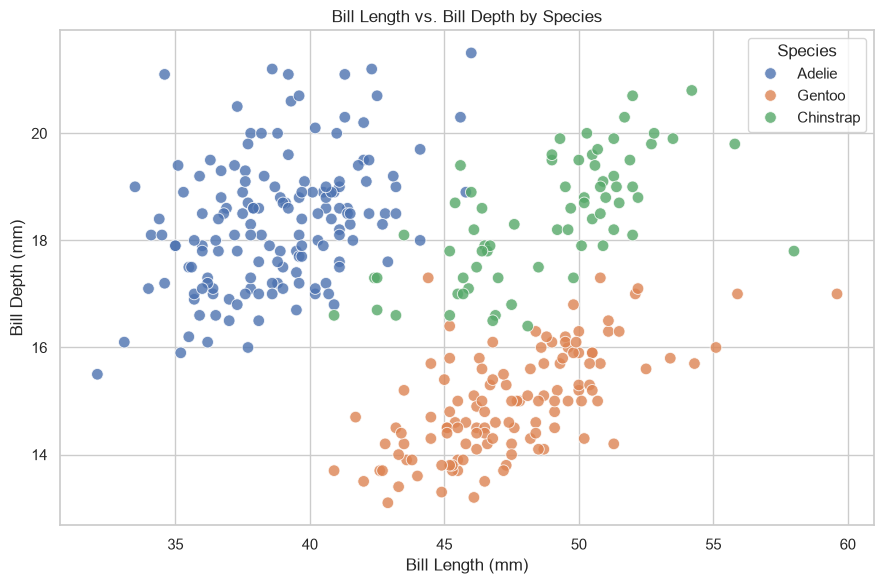

In [11]:
bill_df=eda_df[["bill_length_mm","bill_depth_mm","species"]].dropna()
bill_correlation=bill_df["bill_length_mm"].corr(bill_df["bill_depth_mm"])

print(f"Number of observations used: {len(bill_df)}")
print("Correlation between bill length and bill depth: "f"{bill_correlation:.3f}")

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=bill_df,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    s=70,
    alpha=0.8
)

plt.title("Bill Length vs. Bill Depth by Species")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.legend(title="Species")
plt.tight_layout()
plt.show()

#### Interpretation

The combined data shows a weak negative linear correlation between bill length and bill depth (`r = -0.235`). However, the scatter plot reveals three species-related clusters that the overall correlation coefficient does not describe well.

Adelie penguins generally have shorter and deeper bills. Gentoo penguins tend to have relatively long but shallow bills, while Chinstrap penguins generally have long and deeper bills.

This separation suggests that bill length and bill depth may be useful together for distinguishing penguin species. It also demonstrates why a correlation coefficient should be interpreted alongside the scatter plot and the group structure within the data.

### Bill Length and Flipper Length

The third relationship compares bill length with flipper length.

These measurements describe different physical characteristics. Examining them together can reveal whether species occupy different regions of the plot and whether the combination may be useful for future classification.

Number of observations used: 342
Correlation between bill length and flipper length: 0.656


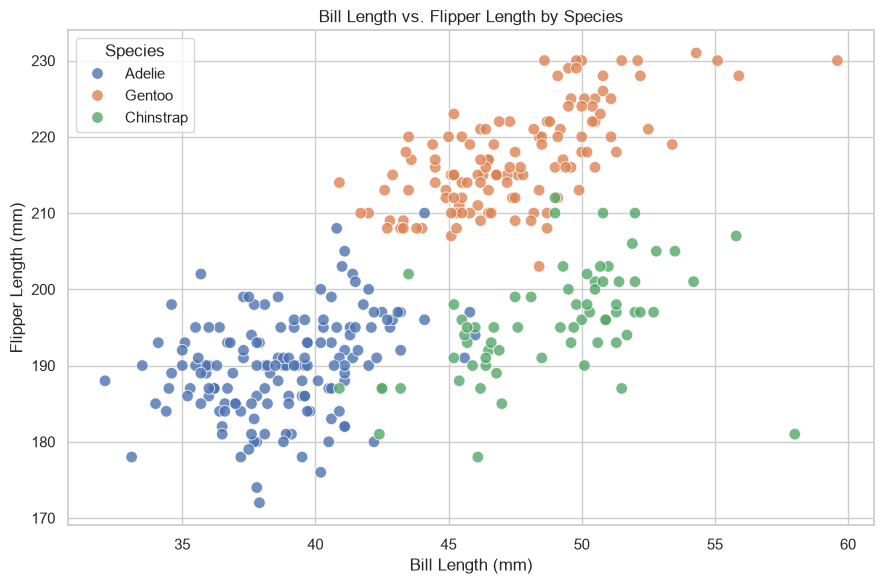

In [12]:
bill_flipper_df = eda_df[
    ["bill_length_mm", "flipper_length_mm", "species"]
].dropna()

bill_flipper_correlation = bill_flipper_df[
    "bill_length_mm"
].corr(bill_flipper_df["flipper_length_mm"])

print(f"Number of observations used: {len(bill_flipper_df)}")

print("Correlation between bill length and flipper length: "f"{bill_flipper_correlation:.3f}")

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=bill_flipper_df,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
    s=70,
    alpha=0.8
)

plt.title("Bill Length vs. Flipper Length by Species")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.legend(title="Species")
plt.tight_layout()
plt.show()

#### Interpretation

Bill length and flipper length have a moderate positive correlation (`r = 0.656`). In the combined dataset, penguins with longer bills tend to have longer flippers, although the relationship is not equally clear within every species.

Gentoo penguins generally have the longest flippers and form a mostly separate group in the upper part of the plot. Adelie penguins usually have shorter bills and shorter flippers, while Chinstrap penguins tend to have longer bills but overlap considerably with Adelie penguins in flipper length.

The combination of these measurements may help distinguish Gentoo penguins and separate parts of the other two groups. However, the visible overlap shows that these two features alone would probably not classify every penguin correctly.

### Numeric Relationship Summary

The scatter plots show that numeric relationships should be interpreted using both the overall trend and the species groups.

Flipper length and body mass describe a strong general size pattern, while the bill measurements reveal important differences between species. Using species colours also shows that an overall correlation value can hide group-specific structure.

These findings suggest that physical measurements can be useful for classification, but feature usefulness should be evaluated from several relationships rather than from one correlation coefficient alone.

## Categorical and Numeric Relationships

A grouped box plot is useful when comparing the distribution of a numeric variable across categories. Unlike a scatter plot, which focuses on individual pairs of numeric values, a box plot summarizes the centre, spread, and possible unusual observations within each group.

The following comparisons examine how physical measurements differ across penguin species and sex groups.

### Body Mass Across Species

This comparison examines whether the distribution of body mass differs between Adelie, Chinstrap, and Gentoo penguins.

If the species have noticeably different medians or ranges, body mass may provide useful information for future species classification.

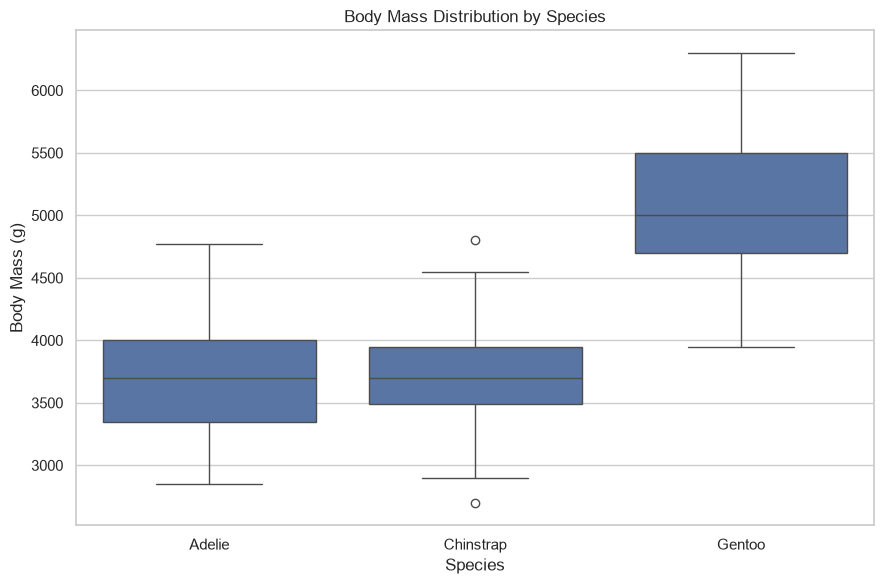

In [13]:
species_order = ["Adelie", "Chinstrap", "Gentoo"]

species_mass_df = eda_df[["species", "body_mass_g"]].dropna()

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=species_mass_df,
    x="species",
    y="body_mass_g",
    order=species_order
)

plt.title("Body Mass Distribution by Species")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.tight_layout()
plt.show()

#### Interpretation

Gentoo penguins have a clearly higher median body mass than Adelie and Chinstrap penguins. Most of the middle 50% of Gentoo body-mass values also lies above the corresponding ranges of the other two species.

Adelie and Chinstrap penguins have similar median body masses and their distributions overlap considerably. The Chinstrap group also contains two observations outside the box-plot whiskers, indicating values that are unusual relative to the rest of that species group.

Body mass may therefore be useful for distinguishing Gentoo penguins from the other species. However, because Adelie and Chinstrap penguins have strongly overlapping distributions, body mass alone would probably not separate those two species reliably.

### Body Mass by Species and Sex

The previous box plot showed that body mass differs between penguin species. However, body mass may also vary between male and female penguins.

Instead of comparing sex groups across the entire dataset, the following plot compares males and females within each species. This avoids mixing the effect of species differences with the comparison between sex groups.

Rows with missing `sex` values are excluded only from this analysis because their true categories are unknown.

Number of observations in each group:


sex,female,male
species,,
Adelie,73,73
Chinstrap,34,34
Gentoo,58,61


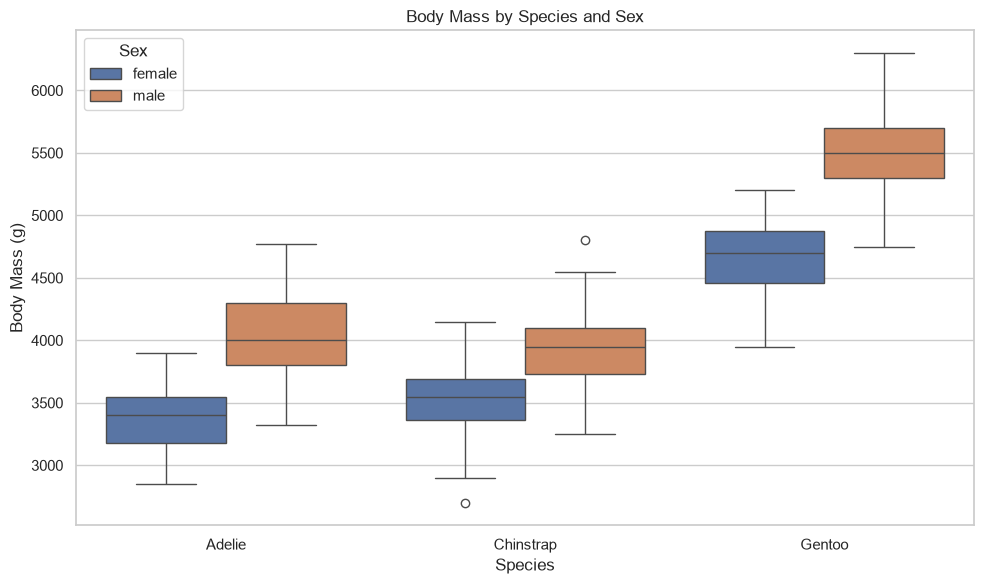

In [14]:
species_sex_mass_df = eda_df[
    ["species", "sex", "body_mass_g"]
].dropna()

group_counts = species_sex_mass_df.groupby(["species", "sex"]).size().unstack(fill_value=0)

print("Number of observations in each group:")
display(group_counts)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=species_sex_mass_df,
    x="species",
    y="body_mass_g",
    hue="sex",
    order=species_order,
    hue_order=["female", "male"]
)

plt.title("Body Mass by Species and Sex")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.legend(title="Sex")
plt.tight_layout()
plt.show()

#### Interpretation

Within each species, male penguins have a higher median body mass than female penguins. The male box plots are also positioned above the female box plots for Adelie, Chinstrap, and Gentoo, showing that the pattern is visible across the middle part of each distribution and not only in a few observations.

Species differences remain clear as well. Gentoo penguins are generally heavier than Adelie and Chinstrap penguins for both sex groups. Adelie and Chinstrap have more similar body-mass ranges.

The group counts are reasonably balanced between females and males, which makes the comparisons more meaningful. Two observations appear outside the whiskers for Chinstrap penguins: one relatively light female and one relatively heavy male. These values are unusual within their groups, but they are not removed because the plot alone does not prove that they are errors.

Overall, body mass is associated with both species and sex. It may be useful in a future classification model, but the overlap between some distributions means that body mass should be combined with other physical measurements.

### Bill Measurements Across Species

The earlier scatter plot showed that bill length and bill depth form species-related clusters when the two measurements are considered together.

The following box plots examine each bill measurement separately. This makes it easier to identify which species differ in bill length, which differ in bill depth, and where the distributions overlap.

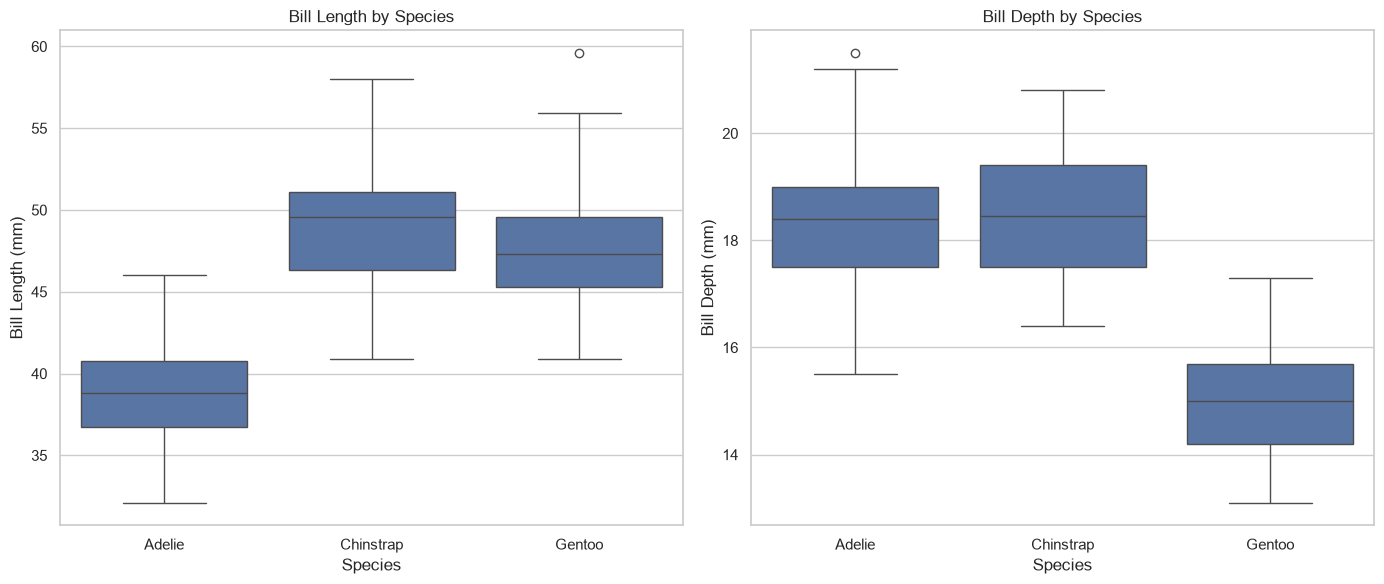

In [15]:
bill_species_df = eda_df[
    ["species", "bill_length_mm", "bill_depth_mm"]
].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=bill_species_df,
    x="species",
    y="bill_length_mm",
    order=species_order,
    ax=axes[0]
)

axes[0].set_title("Bill Length by Species")
axes[0].set_xlabel("Species")
axes[0].set_ylabel("Bill Length (mm)")

sns.boxplot(
    data=bill_species_df,
    x="species",
    y="bill_depth_mm",
    order=species_order,
    ax=axes[1]
)

axes[1].set_title("Bill Depth by Species")
axes[1].set_xlabel("Species")
axes[1].set_ylabel("Bill Depth (mm)")

plt.tight_layout()
plt.show()

#### Interpretation

Bill length and bill depth show different patterns across the three species.

Adelie penguins generally have the shortest bills. Their bill-length distribution is mostly separated from Chinstrap and Gentoo penguins. Chinstrap penguins have the highest median bill length, although their distribution overlaps considerably with Gentoo penguins.

Bill depth shows a different pattern. Gentoo penguins generally have much shallower bills than Adelie and Chinstrap penguins. In contrast, the bill-depth distributions of Adelie and Chinstrap overlap strongly and have very similar medians.

One unusually high bill-length value appears in the Gentoo group, and one unusually high bill-depth value appears in the Adelie group. These observations are retained because the box plots alone do not show that they are data errors.

Neither bill measurement separates all three species perfectly on its own. However, the measurements complement each other: bill length helps distinguish Adelie penguins, while bill depth helps distinguish Gentoo penguins. This explains why considering both measurements together produced clearer species-related clusters in the earlier scatter plot.

### Categorical–Numeric Analysis Summary

The grouped box plots reveal clear physical differences between penguin groups.

Gentoo penguins are generally heavier than Adelie and Chinstrap penguins. Within every species, male penguins also tend to have higher body mass than females.

The bill measurements provide complementary information. Adelie penguins generally have shorter bills, while Gentoo penguins generally have shallower bills. The overlap visible in several distributions shows that no single physical measurement is likely to separate every species correctly.

A future classification model would therefore benefit from combining body mass, flipper length, bill length, and bill depth rather than relying on only one feature.

## Correlation Matrix and Heatmap

The previous scatter plots examined selected numeric relationships individually. The following correlation matrix brings all four physical measurements together in one view, making it easier to compare the relationships and identify the strongest pairs.

The `year` column is excluded because it represents the collection year rather than a physical measurement.

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000,-0.235,0.656,0.595
bill_depth_mm,-0.235,1.000,-0.584,-0.472
flipper_length_mm,0.656,-0.584,1.000,0.871
body_mass_g,0.595,-0.472,0.871,1.000


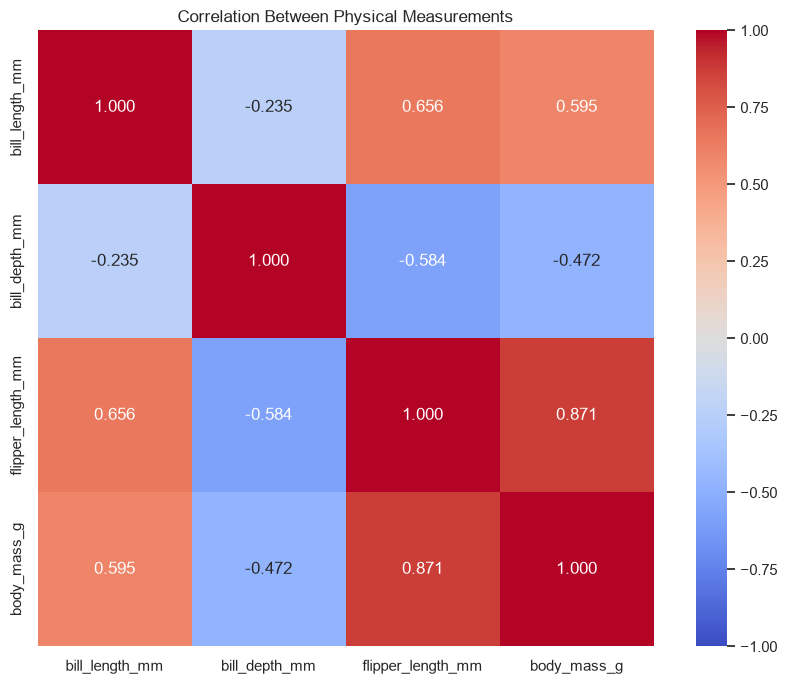

In [16]:
correlation_matrix = (
    eda_df[measurement_columns]
    .corr()
    .round(3)
)

display(correlation_matrix)

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

plt.title("Correlation Between Physical Measurements")
plt.tight_layout()
plt.show()

#### Interpretation

The strongest relationship is between flipper length and body mass (`r = 0.871`). This confirms the earlier scatter plot: penguins with longer flippers generally tend to have greater body mass.

Bill length also has moderate positive relationships with flipper length (`r = 0.656`) and body mass (`r = 0.595`). These measurements may therefore carry useful information about physical size and species differences.

Bill depth has negative overall relationships with flipper length (`r = -0.584`) and body mass (`r = -0.472`). Part of these patterns is connected to the species groups, especially the relatively shallow bills and larger body measurements of Gentoo penguins.

The weak overall relationship between bill length and bill depth (`r = -0.235`) does not mean that the measurements are unimportant. The earlier scatter plot showed that their combination forms useful species-related clusters.

These correlations describe association rather than causation. Strongly related features may also contain some overlapping information, but no feature will be removed before its value is tested during modeling.

## Pairwise Overview

The correlation heatmap summarizes linear relationships numerically, while a pairplot shows the distributions and pairwise patterns directly.

Only the four physical measurements and the species label are included so that the figure remains focused on the variables most relevant to possible species classification.

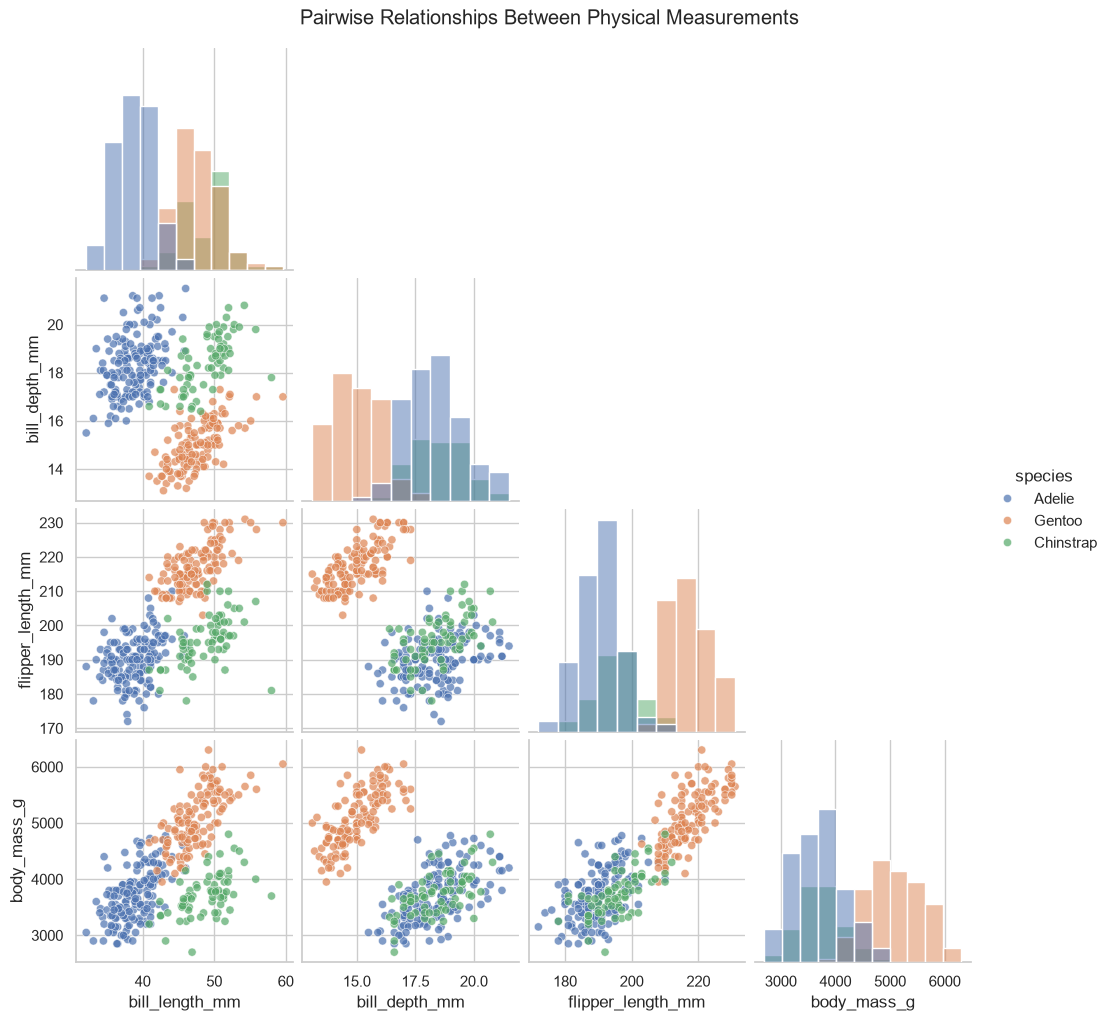

In [17]:
pairplot_df = eda_df[
    ["species"] + measurement_columns
].dropna()

pair_grid = sns.pairplot(
    pairplot_df,
    hue="species",
    diag_kind="hist",
    corner=True,
    plot_kws={
        "alpha": 0.7,
        "s": 35
    }
)

pair_grid.fig.suptitle(
    "Pairwise Relationships Between Physical Measurements",
    y=1.02
)

plt.show()

#### Interpretation

The pairplot confirms that Gentoo penguins form the clearest physical group. They generally have longer flippers, greater body mass, and shallower bills than the other species.

Adelie penguins usually have shorter bills and lower body measurements. Chinstrap penguins tend to have longer and deeper bills, but they overlap with Adelie penguins in flipper length and body mass.

The strongest visible numeric pattern remains the relationship between flipper length and body mass. The bill measurements provide additional information that helps separate species which overlap in general body size.

The figure confirms that no single measurement separates every species perfectly. Combining several physical features is likely to be more useful for future classification than relying on one variable alone.

## Main Findings and Data Story

The Palmer Penguins dataset contains clear physical differences between species, but the useful information is distributed across several measurements.

The strongest numeric relationship is between flipper length and body mass. Gentoo penguins generally occupy the larger-body region of the dataset, with longer flippers and greater body mass. They also tend to have shallower bills.

Adelie penguins generally have shorter bills, while Chinstrap penguins tend to have longer and deeper bills. Bill length and bill depth are especially useful when considered together because their overall correlation alone does not reveal the species clusters.

Sex is also associated with body mass. Within each species, male penguins generally have a higher median body mass than female penguins.

The overlap between some groups shows that one measurement alone would not be enough for reliable species classification. The most useful future approach would combine multiple physical measurements.

## Implications for Future Modeling

A natural future task for this dataset would be a classification model that predicts `species`.

The four physical measurements are reasonable candidate features because each provides useful information:

- `flipper_length_mm` and `body_mass_g` describe general body size;
- `bill_length_mm` helps distinguish Adelie penguins;
- `bill_depth_mm` helps distinguish Gentoo penguins;
- the combination of bill measurements helps separate species more clearly than either measurement alone.

Missing values will need to be handled inside the preprocessing stage. The strong correlation between flipper length and body mass should also be monitored, but it is not a reason to remove either feature before comparing model performance.

## Conclusion

This notebook completed an exploratory analysis of the Palmer Penguins dataset by combining data-quality checks, descriptive summaries, univariate analysis, outlier investigation, bivariate comparisons, correlation analysis, and data storytelling.

The analysis found that penguin species differ across several physical measurements. Flipper length and body mass have the strongest numeric relationship, while bill measurements provide complementary information for separating species.

The results support using multiple physical features in a future classification model. The next stage should focus on preprocessing the data, splitting it correctly, training classification models, and evaluating whether the patterns discovered during EDA improve prediction.